In [1]:
import sys
import os

project_root = os.path.dirname(os.path.abspath(''))  # Directorio actual del notebook
src_path = os.path.join(project_root, 'src')
sys.path.append(src_path)

from data_prep import Eda
import pandas as pd


## Paso 1: Acceso y preparación de los datos

In [2]:
costos = pd.read_csv('../data/raw/costs_us.csv')
visitas = pd.read_csv('../data/raw/visits_log_us.csv')
ordenes = pd.read_csv('../data/raw/orders_log_us.csv')

In [3]:
costos.head()

,source_id,dt,costs
0,1,2017-06-01,75.20
1,1,2017-06-02,62.25
2,1,2017-06-03,36.53
3,1,2017-06-04,55.00
4,1,2017-06-05,57.08


|                                                Análisis de la tabla Costos                                                |
Dimensiones: (2542, 3)



Estadísticas descriptivas y problemas de calidad:
|                               | source_id       | dt              | costs              |
|:------------------------------|:----------------|:----------------|:-------------------|
| Valores Únicos                | 7               | 364             | 2396               |
| Media                         | -               | -               | 129.47742722265932 |
| Desviación Estándar           | -               | -               | 156.29662779712575 |
| Mínimo                        | 1               | -               | 0.54               |
| Mediana                       | -               | -               | 77.295             |
| Máximo                        | 10              | -               | 1788.28            |
| Tipos de datos                | [<class 'int'>] | [<class 'str'>] | [<class 'float'>]  |
| NaN/Null                      | 0               | 0               | 0                  |
| Duplicados únicos             | 2535 

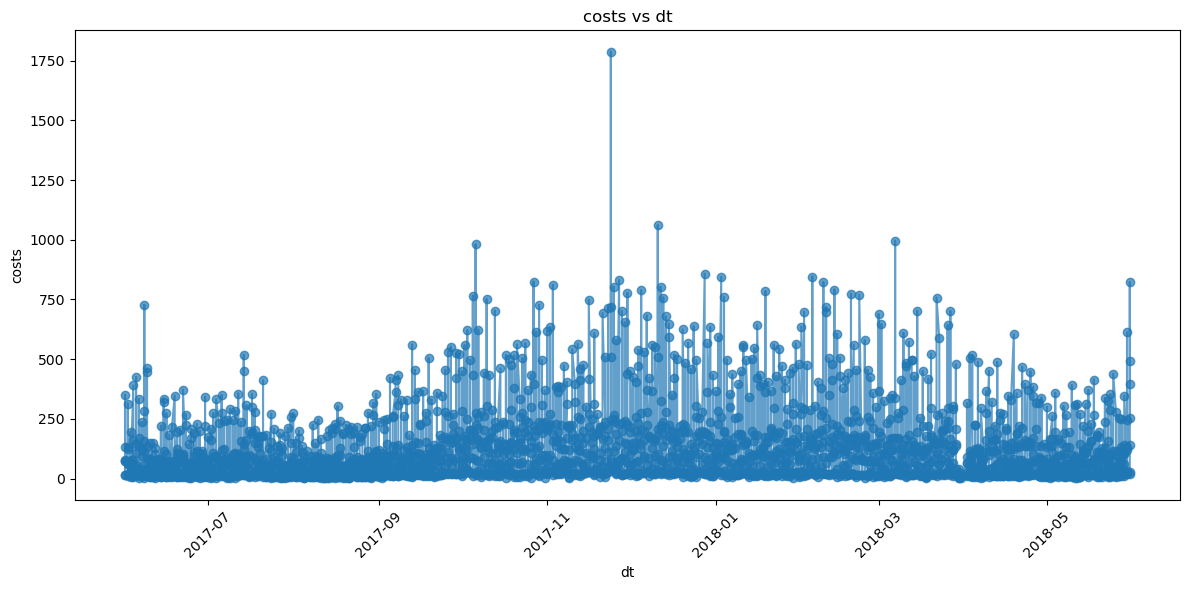

In [4]:
Eda.analisis_exploratorio("Costos", costos, "costs")

Analizando algunos aspectos de calidad e integridad de los datos se observa que costos esta limpio. Solo hay que convertir algunas columnas a su tipo de dato adecuado

In [5]:
costos['dt'] = pd.to_datetime(costos['dt'])
costos['dt']

0      2017-06-01
1      2017-06-02
2      2017-06-03
3      2017-06-04
4      2017-06-05
          ...    
2537   2018-05-27
2538   2018-05-28
2539   2018-05-29
2540   2018-05-30
2541   2018-05-31
Name: dt, Length: 2542, dtype: datetime64[ns]

In [6]:
costos.to_csv('../data/interim/costs.csv', index=False)

In [7]:
visitas.head()

,Device,End Ts,Source Id,Start Ts,Uid
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168


In [8]:
Eda.analisis_exploratorio("Vistas", visitas)

|                                                Análisis de la tabla Vistas                                                |
Dimensiones: (359400, 5)

Estadísticas descriptivas y problemas de calidad:
|                               | device          | end_ts          | source_id       | start_ts        | uid             |
|:------------------------------|:----------------|:----------------|:----------------|:----------------|:----------------|
| Valores Únicos                | 2               | 224760          | 9               | 224303          | 228169          |
| Media                         | -               | -               | -               | -               | -               |
| Desviación Estándar           | -               | -               | -               | -               | -               |
| Mínimo                        | -               | -               | 1               | -               | -               |
| Mediana                       | -               | - 

Analizando algunos aspectos de calidad e integridad de los datos se observa que costos esta limpio. Solo hay que convertir algunas columnas a su tipo de dato adecuado y normalizar las columnas

In [9]:
visitas.columns = Eda.standarize_columns(visitas.columns)
visitas.columns

Index(['device', 'end_ts', 'source_id', 'start_ts', 'uid'], dtype='object')

In [10]:
visitas['uid'] = visitas['uid'].astype(str)
visitas['uid']

0         16879256277535980062
1           104060357244891740
2          7459035603376831527
3         16174680259334210214
4          9969694820036681168
                  ...         
359395    18363291481961487539
359396    18370831553019119586
359397    18387297585500748294
359398    18388616944624776485
359399    18396128934054549559
Name: uid, Length: 359400, dtype: object

In [11]:
visitas['end_ts'] = pd.to_datetime(visitas['end_ts'])
visitas['end_ts']

0        2017-12-20 17:38:00
1        2018-02-19 17:21:00
2        2017-07-01 01:54:00
3        2018-05-20 11:23:00
4        2017-12-27 14:06:00
                 ...        
359395   2017-07-29 19:07:19
359396   2018-01-25 17:38:19
359397   2018-03-03 10:12:19
359398   2017-11-02 10:12:19
359399   2017-09-10 13:13:19
Name: end_ts, Length: 359400, dtype: datetime64[ns]

In [12]:
visitas['start_ts'] = pd.to_datetime(visitas['start_ts'])
visitas['start_ts']

0        2017-12-20 17:20:00
1        2018-02-19 16:53:00
2        2017-07-01 01:54:00
3        2018-05-20 10:59:00
4        2017-12-27 14:06:00
                 ...        
359395   2017-07-29 19:07:00
359396   2018-01-25 17:38:00
359397   2018-03-03 10:12:00
359398   2017-11-02 10:12:00
359399   2017-09-10 13:13:00
Name: start_ts, Length: 359400, dtype: datetime64[ns]

In [13]:
visitas.to_csv('../data/interim/visitas.csv', index=False)

In [14]:
ordenes.head()

,Buy Ts,Revenue,Uid
0,2017-06-01 00:10:00,17.00,10329302124590727494
1,2017-06-01 00:25:00,0.55,11627257723692907447
2,2017-06-01 00:27:00,0.37,17903680561304213844
3,2017-06-01 00:29:00,0.55,16109239769442553005
4,2017-06-01 07:58:00,0.37,14200605875248379450


|                                                Análisis de la tabla Ordenes                                               |
Dimensiones: (50415, 3)



Estadísticas descriptivas y problemas de calidad:
|                               | buy_ts          | revenue            | uid             |
|:------------------------------|:----------------|:-------------------|:----------------|
| Valores Únicos                | 45991           | 1149               | 36523           |
| Media                         | -               | 4.999646930477041  | -               |
| Desviación Estándar           | -               | 21.818358802281068 | -               |
| Mínimo                        | -               | 0.0                | -               |
| Mediana                       | -               | 2.5                | -               |
| Máximo                        | -               | 2633.28            | -               |
| Tipos de datos                | [<class 'str'>] | [<class 'float'>]  | [<class 'int'>] |
| NaN/Null                      | 0               | 0                  | 0               |
| Duplicados únicos             | 4424 

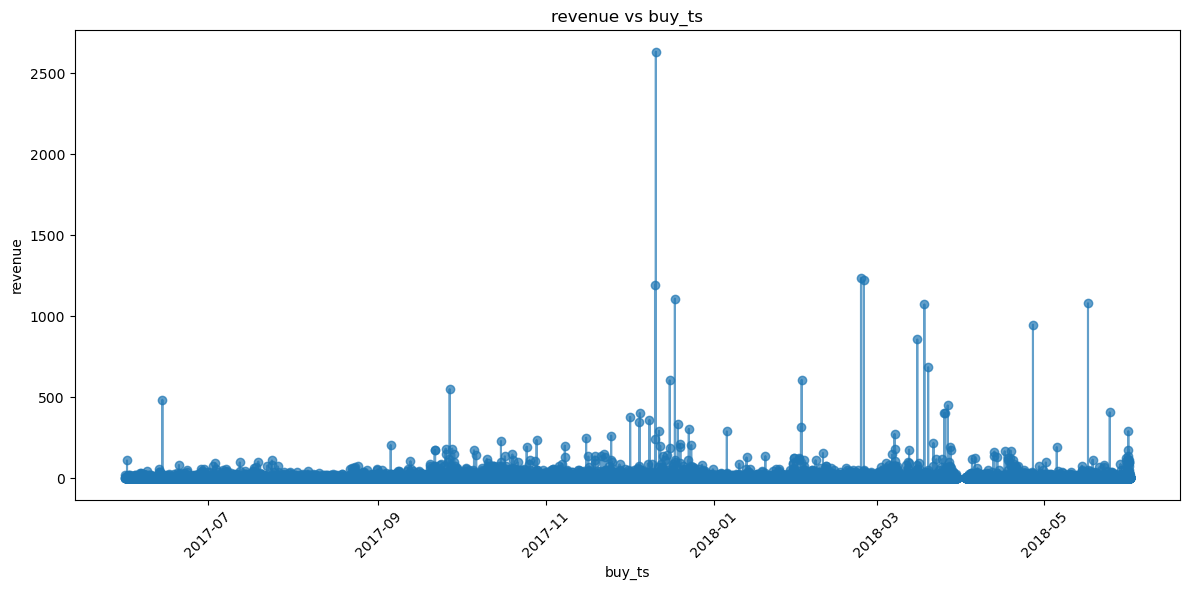

In [15]:
Eda.analisis_exploratorio("Ordenes", ordenes, "revenue")

Analizando algunos aspectos de calidad e integridad de los datos se observa que costos esta limpio. Solo hay que convertir algunas columnas a su tipo de dato adecuado y normalizar las columnas


In [16]:
ordenes.columns = Eda.standarize_columns(ordenes.columns)
ordenes.columns

Index(['buy_ts', 'revenue', 'uid'], dtype='object')

In [17]:
ordenes['buy_ts'] = pd.to_datetime(ordenes['buy_ts'])
ordenes['buy_ts']

0       2017-06-01 00:10:00
1       2017-06-01 00:25:00
2       2017-06-01 00:27:00
3       2017-06-01 00:29:00
4       2017-06-01 07:58:00
                ...        
50410   2018-05-31 23:50:00
50411   2018-05-31 23:50:00
50412   2018-05-31 23:54:00
50413   2018-05-31 23:56:00
50414   2018-06-01 00:02:00
Name: buy_ts, Length: 50415, dtype: datetime64[ns]

In [18]:
ordenes['uid'] = ordenes['uid'].astype(str)
ordenes['uid']

0        10329302124590727494
1        11627257723692907447
2        17903680561304213844
3        16109239769442553005
4        14200605875248379450
                 ...         
50410    12296626599487328624
50411    11369640365507475976
50412     1786462140797698849
50413     3993697860786194247
50414       83872787173869366
Name: uid, Length: 50415, dtype: object

In [19]:
ordenes.to_csv('../data/interim/ordenes.csv', index=False)

In [20]:
del ordenes
del visitas
del costos

## Paso 2. Cálculo de métricas e informes

In [21]:
costos = pd.read_csv('../data/interim/costs.csv', low_memory=False)
visitas = pd.read_csv('../data/interim/visitas.csv', low_memory=False)
ordenes = pd.read_csv('../data/interim/ordenes.csv', low_memory=False)

### A. Vsitas
A.1) ¿Cuántas personas visitan la pagina usan cada día, semana y mes? (DAU, WAU, MAU ).


In [22]:
visitas['start_ts'] = pd.to_datetime(visitas['start_ts'])
visitas['end_ts'] = pd.to_datetime(visitas['end_ts'])

In [23]:
visitas['fecha_sesion'] = visitas['start_ts'].dt.date
visitas['semana'] = visitas['start_ts'].dt.to_period('W').apply(lambda r: r.start_time)
visitas['mes'] = pd.to_datetime(visitas['start_ts'].dt.strftime('%Y-%m-01'))

In [24]:
visitas

,device,end_ts,source_id,start_ts,uid,fecha_sesion,semana,mes
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062,2017-12-20,2017-12-18,2017-12-01
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740,2018-02-19,2018-02-19,2018-02-01
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527,2017-07-01,2017-06-26,2017-07-01
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214,2018-05-20,2018-05-14,2018-05-01
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168,2017-12-27,2017-12-25,2017-12-01
...,...,...,...,...,...,...,...,...
359395,desktop,2017-07-29 19:07:19,2,2017-07-29 19:07:00,18363291481961487539,2017-07-29,2017-07-24,2017-07-01
359396,touch,2018-01-25 17:38:19,1,2018-01-25 17:38:00,18370831553019119586,2018-01-25,2018-01-22,2018-01-01
359397,desktop,2018-03-03 10:12:19,4,2018-03-03 10:12:00,18387297585500748294,2018-03-03,2018-02-26,2018-03-01
359398,desktop,2017-11-02 10:12:19,5,2017-11-02 10:12:00,18388616944624776485,2017-11-02,2017-10-30,2017-11-01


In [25]:
dau = visitas.groupby('fecha_sesion').agg({'uid': 'nunique'})
wau = visitas.groupby('semana').agg({'uid': 'nunique'})
mau = visitas.groupby('mes').agg({'uid': 'nunique'})

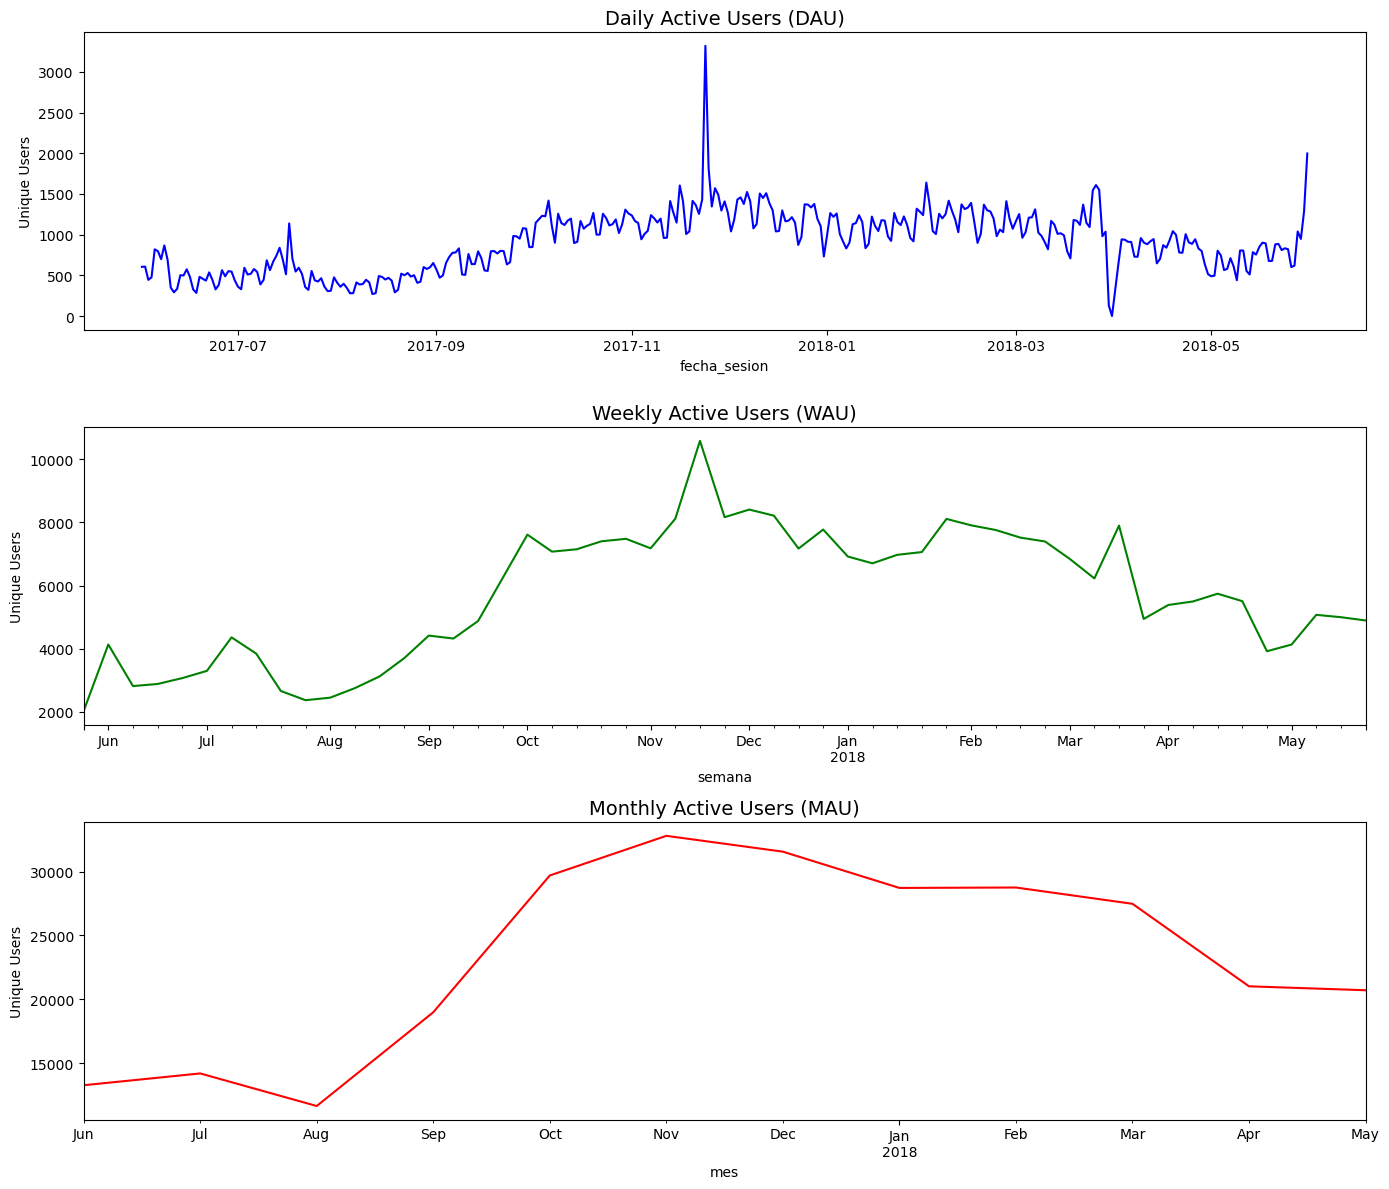

Average DAU: 908
Average WAU: 5716
Average MAU: 23228


<Figure size 640x480 with 0 Axes>

In [26]:
from matplotlib.ticker import FuncFormatter
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=False)

dau.plot(ax=axes[0], color='blue', legend=False)
axes[0].set_title('Daily Active Users (DAU)', fontsize=14)
axes[0].set_ylabel('Unique Users')

wau.plot(ax=axes[1], color='green', legend=False)
axes[1].set_title('Weekly Active Users (WAU)', fontsize=14)
axes[1].set_ylabel('Unique Users')

mau.plot(ax=axes[2], color='red', legend=False)
axes[2].set_title('Monthly Active Users (MAU)', fontsize=14)
axes[2].set_ylabel('Unique Users')

plt.tight_layout()
plt.show()
plt.savefig('../reports/figures/DAU_WAU_MAU.png', dpi=300, bbox_inches='tight')

print(f"Average DAU: {dau['uid'].mean():.0f}")
print(f"Average WAU: {wau['uid'].mean():.0f}")
print(f"Average MAU: {mau['uid'].mean():.0f}")

Se identifica un crecimiento sostenido en el número de usuarios activos desde mediados hasta finales de 2017.

A finales de 2017, se produce un aumento significativo en la actividad, posiblemente asociado a campañas de marketing o eventos puntuales.

A partir de enero de 2018, la cifra de usuarios activos se estabiliza y luego muestra una leve disminución.


A.2) ¿Cuántas sesiones hay por día? (Un usuario puede tener más de una sesión).


,sesiones
fecha_sesion,
2017-06-01,664
2017-06-02,658
2017-06-03,477
2017-06-04,510
2017-06-05,893
...,...
2018-05-27,672
2018-05-28,1156
2018-05-29,1035


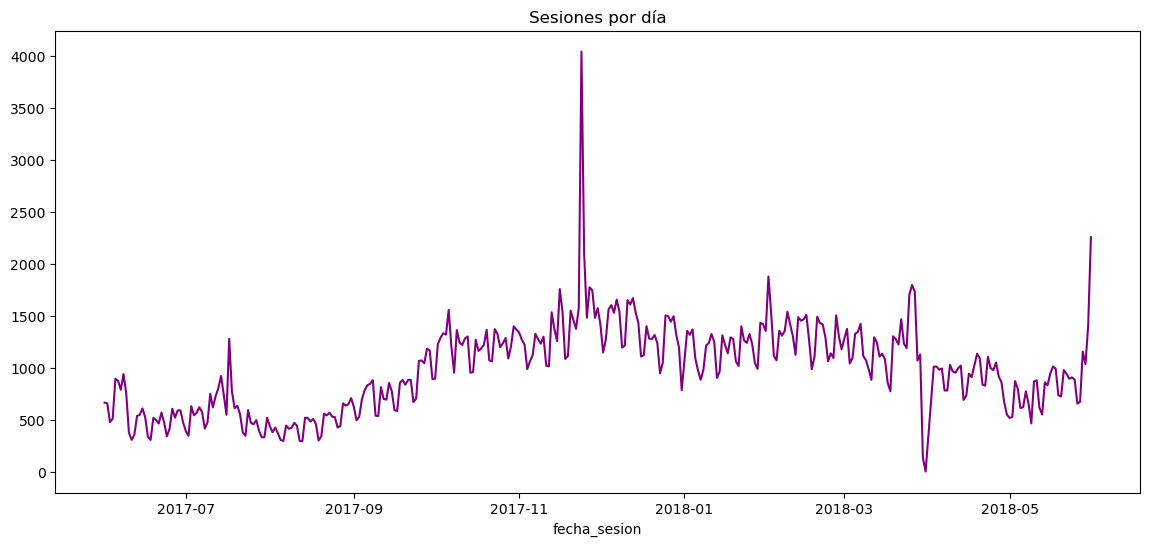

In [27]:
sesiones_por_dia = visitas.groupby('fecha_sesion').agg({'uid': 'count'})
sesiones_por_dia.rename(columns={'uid': 'sesiones'}, inplace=True)
fig, ax = plt.subplots(figsize=(14, 6))
ax.title.set_text('Sesiones por día')
sesiones_por_dia.plot(ax=ax, figsize=(14, 6), color='purple', legend=False)
fig.savefig('../reports/figures/sesiones_x_dia.png', dpi=300, bbox_inches='tight')
sesiones_por_dia

In [28]:
print(f"Promedio sesiones por día: {sesiones_por_dia['sesiones'].mean()}")
print(f"Máximo sesiones por día: {sesiones_por_dia['sesiones'].max()}")
print(f"Mínimo sesiones por día: {sesiones_por_dia['sesiones'].min()}")
print(f"Moda sesiones por día: {sesiones_por_dia['sesiones'].mode()[0]}")

Promedio sesiones por día: 987.3626373626373
Máximo sesiones por día: 4042
Mínimo sesiones por día: 1
Moda sesiones por día: 884


La evolución de las sesiones diarias refleja el mismo comportamiento observado en los usuarios activos, con un pico notable hacia finales de 2017.

El promedio de sesiones por día es de 987, teniendo como minimo 1 sesión, un máximo 4042 sesiones en un día y una moda de 884


A.3) ¿Cuál es la duración de cada sesión? (End_Ts - Start_Ts).


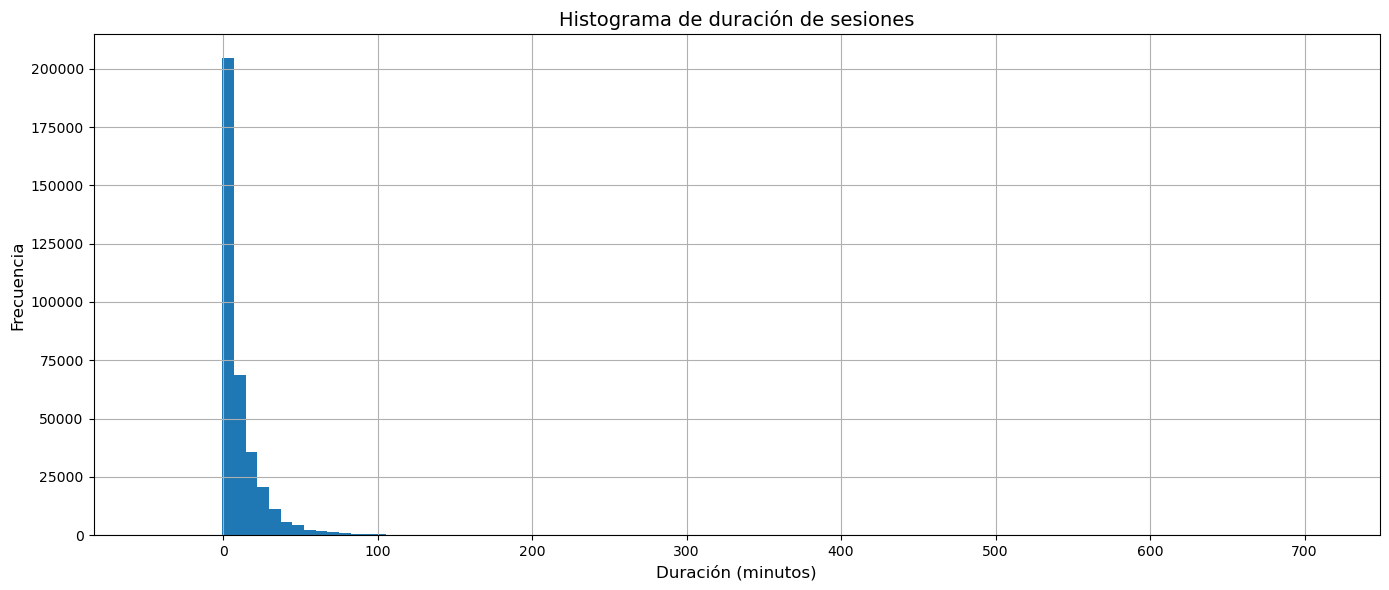

In [29]:
visitas['duracion'] = ((visitas['end_ts'] - visitas['start_ts']).dt.total_seconds())
visitas['duracion_minutos'] = visitas['duracion'] / 60

fig, ax = plt.subplots(figsize=(14, 6))
ax.set_title('Histograma de duración de sesiones', fontsize=14)
ax.set_xlabel('Duración (minutos)', fontsize=12)
ax.set_ylabel('Frecuencia', fontsize=12)

visitas['duracion_minutos'].hist(ax=ax, bins=100)
plt.tight_layout()
plt.savefig('../reports/figures/duracion_sesiones.png', dpi=300, bbox_inches='tight')

In [30]:
print(f"media segundos:{float(visitas['duracion'].mean())}, media minutos: {float(visitas['duracion_minutos'].mean())}")

media segundos:643.0256872565387, media minutos: 10.717094787608978


La mayoría de las sesiones tienen una duración alrededor de los 10 minutos.

La distribución presenta una asimetría positiva, indicando que pocas sesiones superan los 30 minutos.


A.4) ¿Con qué frecuencia los usuarios regresan?

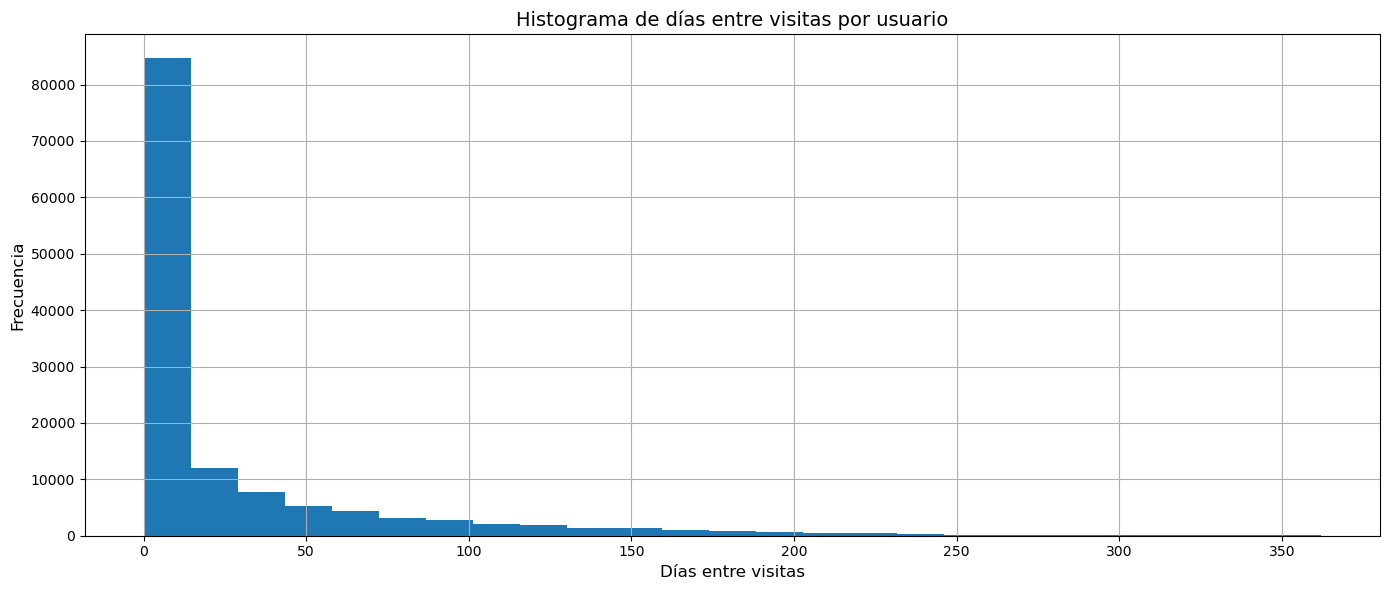

In [31]:
visitas_sorted = visitas.sort_values(['uid', 'start_ts'])

# Calcula la diferencia entre sesiones por usuario
visitas_sorted['prev_start_ts'] = visitas_sorted.groupby('uid')['start_ts'].shift(1)
visitas_sorted['dias_entre_visitas'] = (visitas_sorted['start_ts'] - visitas_sorted['prev_start_ts']).dt.days

fig, ax = plt.subplots(figsize=(14, 6))
visitas_sorted['dias_entre_visitas'].hist(ax=ax, bins=25)
ax.set_title('Histograma de días entre visitas por usuario', fontsize=14)
ax.set_xlabel('Días entre visitas', fontsize=12)
ax.set_ylabel('Frecuencia', fontsize=12)
plt.tight_layout()
plt.savefig('../reports/figures/dias_entre_visitas.png', dpi=300, bbox_inches='tight')

Una gran proporción de usuarios regresa dentro de los 10 días posteriores a su última sesión.

A medida que aumenta el intervalo entre visitas, la frecuencia de retorno disminuye notablemente, aunque hay usuarios que regresan tras períodos prolongados, hasta 200 días después.

### B. Ventas 
B.1) ¿Cuándo empieza la gente a comprar? (En el análisis de KPI, generalmente nos interesa
saber el tiempo que transcurre entre el registro y la conversión, es decir, cuando el usuario
se convierte en cliente. Por ejemplo, si el registro y la primera compra ocurren el mismo
día, el usuario podría caer en la categoría Conversion 0d. Si la primera compra ocurre al
día siguiente, será Conversion 1d. Puedes usar cualquier enfoque que te permita comparar
las conversiones de diferentes cohortes para que puedas determinar qué cohorte o canal
de marketing es más efectivo.)


In [32]:
ordenes['buy_ts'] = pd.to_datetime(ordenes['buy_ts'])

In [45]:
from metrics import generar_cohortes_conversion

cohortes_conversion = generar_cohortes_conversion(visitas, ordenes)
cohortes_conversion.to_csv('../data/processed/cohortes_conversion.csv', index=False)
cohortes_conversion

Max conversion days: 363
Min conversion days: 0


,uid,first_visit,first_purchase,conversion_days,conversion_category
0,313578113262317,2017-09-18 22:49:00,2018-01-03 21:51:00,106,Conversion 106d
1,1575281904278712,2017-06-03 10:13:00,2017-06-03 10:13:00,0,Conversion 0d
2,2429014661409475,2017-10-11 17:14:00,2017-10-11 18:33:00,0,Conversion 0d
3,2464366381792757,2018-01-27 20:10:00,2018-01-28 15:54:00,0,Conversion 0d
4,2551852515556206,2017-11-24 10:14:00,2017-11-24 10:14:00,0,Conversion 0d
...,...,...,...,...,...
36518,18445147675727495770,2017-08-20 13:30:00,2017-11-24 09:03:00,95,Conversion 95d
36519,18445407535914413204,2017-09-22 23:48:00,2017-09-22 23:55:00,0,Conversion 0d
36520,18445601152732270159,2017-08-07 11:51:00,2018-03-26 22:54:00,231,Conversion 231d
36521,18446156210226471712,2017-11-07 10:01:00,2018-02-18 19:34:00,103,Conversion 103d


In [34]:
cohortes_conversion['conversion_days'].describe()

count    36523.000000
mean        16.729869
std         46.959088
min          0.000000
25%          0.000000
50%          0.000000
75%          2.000000
max        363.000000
Name: conversion_days, dtype: float64

Ya que la media son 16 días y la desviación estandar 46 vamos a coger 60 días para plotear

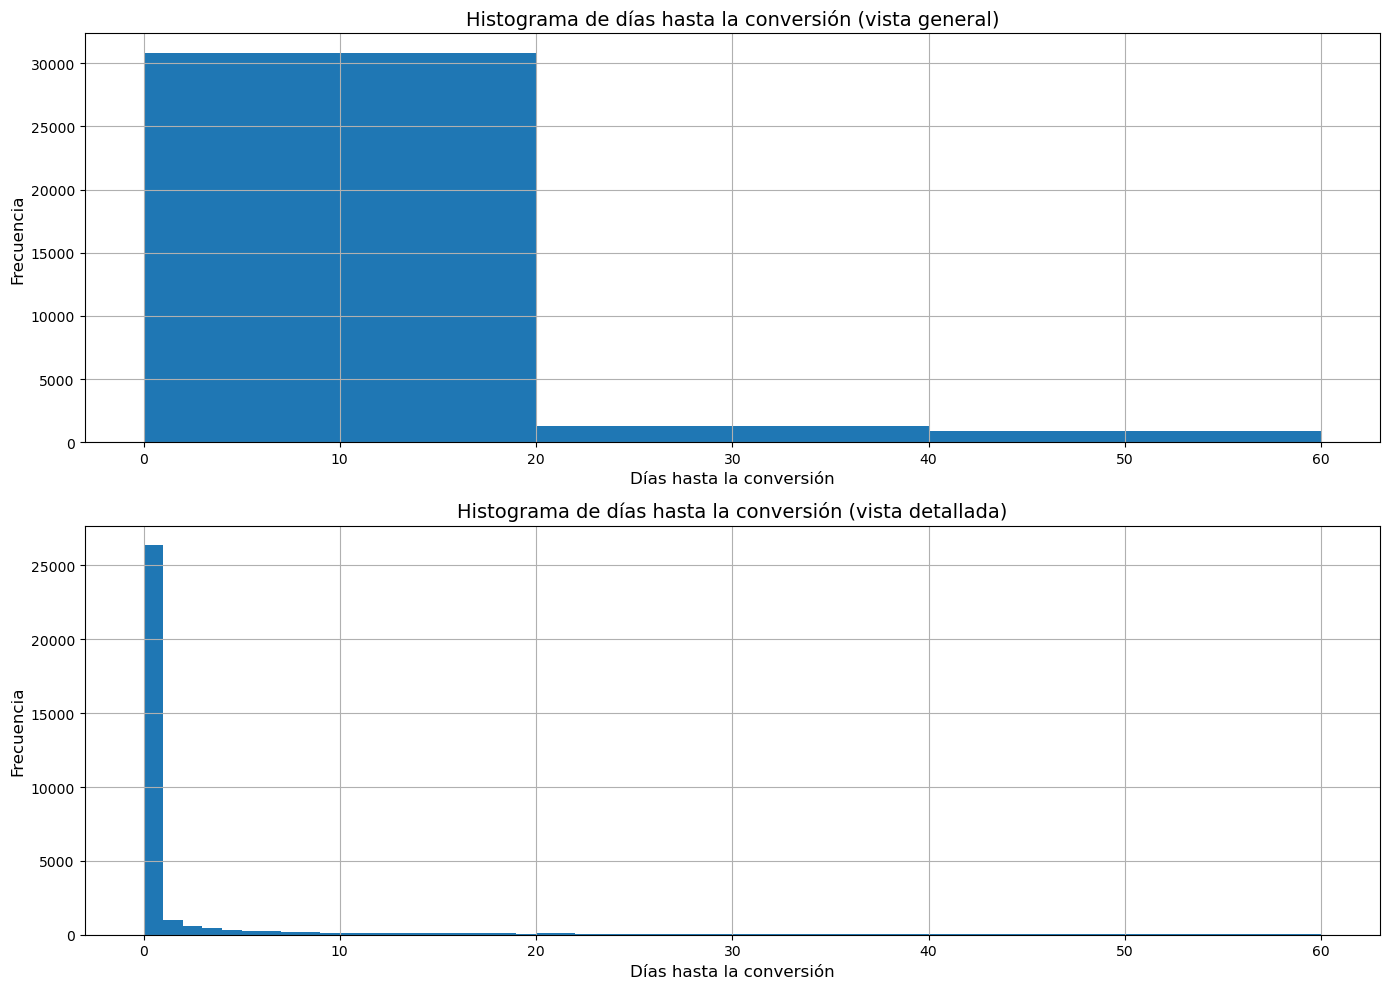

In [35]:
cohortes_conversion = cohortes_conversion[cohortes_conversion['conversion_days'] <= 60]
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# First histogram with fewer bins for general overview
cohortes_conversion['conversion_days'].hist(ax=axes[0], bins=3)
axes[0].set_title('Histograma de días hasta la conversión (vista general)', fontsize=14)
axes[0].set_xlabel('Días hasta la conversión', fontsize=12)
axes[0].set_ylabel('Frecuencia', fontsize=12)

# Second histogram with more bins for detailed view
cohortes_conversion['conversion_days'].hist(ax=axes[1], bins=60)
axes[1].set_title('Histograma de días hasta la conversión (vista detallada)', fontsize=14)
axes[1].set_xlabel('Días hasta la conversión', fontsize=12)
axes[1].set_ylabel('Frecuencia', fontsize=12)

plt.tight_layout()
plt.savefig('../reports/figures/dias_hasta_conversion.png', dpi=300, bbox_inches='tight')

La conversión es mayormente inmediata: más de 25,000 usuarios realizaron su primera compra el mismo día que visitaron el sitio (0 días de diferencia).

Aunque hay casos en los que la conversión ocurre 1 o más días después, estos son menos frecuentes. Alrededor de 3000 o 4000 a los 20 días.


B.2) ¿Cuántos pedidos hacen durante un período de tiempo dado?


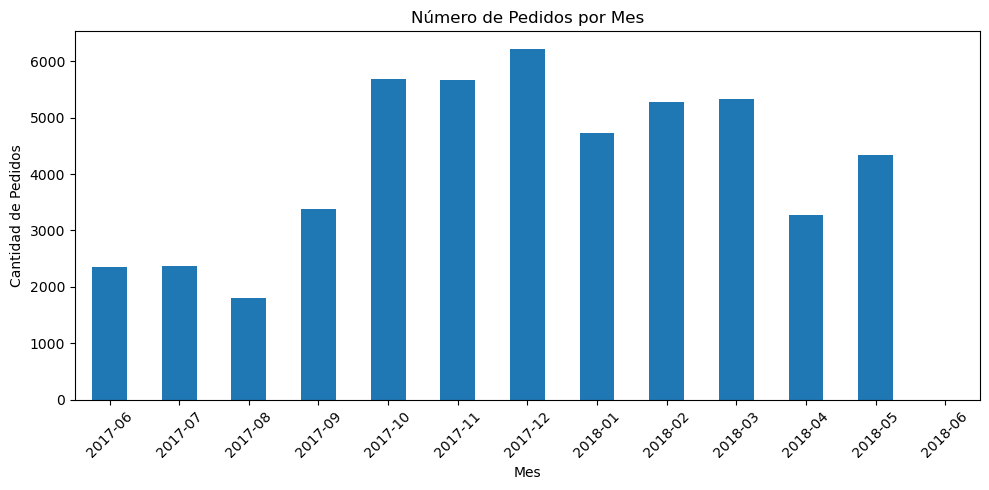

In [36]:
ordenes['month'] = ordenes['buy_ts'].dt.to_period('M')

# Agrupar por mes
compras_por_mes = ordenes.groupby('month').size()

compras_por_mes.plot(kind='bar', figsize=(10, 5))
plt.title('Número de Pedidos por Mes')
plt.xlabel('Mes')
plt.ylabel('Cantidad de Pedidos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/figures/compras_por_mes.png', dpi=300, bbox_inches='tight')


Se nota una tendencia de crecimiento sostenido desde junio de 2017 hasta enero de 2018, alcanzando su punto más alto en diciembre de 2017.

A partir de enero de 2018, el número de pedidos se estabiliza y muestra una leve disminución.


B.3) ¿Cuál es el tamaño promedio de compra? Ticket promedio.


In [37]:
print(f"Promedio ticket: {ordenes['revenue'].mean()}")

Promedio ticket: 4.999646930477041


Este valor bajo sugiere que las ventas corresponden principalmente a productos de bajo precio, como entradas individuales.

El modelo de ingresos parece estar basado en un alto volumen de transacciones más que en compras de alto valor.


B.4) ¿Cuánto dinero traen? Lifetime Value (LTV) por cohorte


In [ ]:
from metrics import calcular_ltv_por_cohorte
ltv = calcular_ltv_por_cohorte(visitas, ordenes)
ltv.to_csv('../data/processed/ltv.csv', index=False)
ltv

months_since_acquisition,0,1,2,3,4,5,6,7,8,9,10,11
cohort_month,,,,,,,,,,,,
2017-06,0.720830,0.200964,0.110468,0.292789,0.297201,0.213024,0.263214,0.171266,0.174818,0.262587,0.166227,0.145396
2017-07,0.751514,0.080615,0.084391,0.074807,0.064459,0.060737,0.044749,0.058623,0.055139,0.044979,0.035553,NaN
2017-08,0.612397,0.097959,0.098355,0.092939,0.079564,0.052343,0.047800,0.122407,0.081587,0.036904,NaN,NaN
2017-09,0.739775,0.221533,0.126355,0.624936,0.077136,0.114347,0.057881,0.029417,0.025058,NaN,NaN,NaN
2017-10,0.706868,0.146662,0.051084,0.040730,0.040169,0.039350,0.022285,0.025249,NaN,NaN,NaN,NaN
2017-11,0.606716,0.097900,0.049283,0.050262,0.040691,0.025970,0.025639,NaN,NaN,NaN,NaN,NaN
2017-12,0.667128,0.068823,0.166151,0.202779,0.057684,0.070529,NaN,NaN,NaN,NaN,NaN,NaN
2018-01,0.468397,0.086267,0.051483,0.013520,0.023315,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-02,0.518657,0.089402,0.029877,0.040592,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


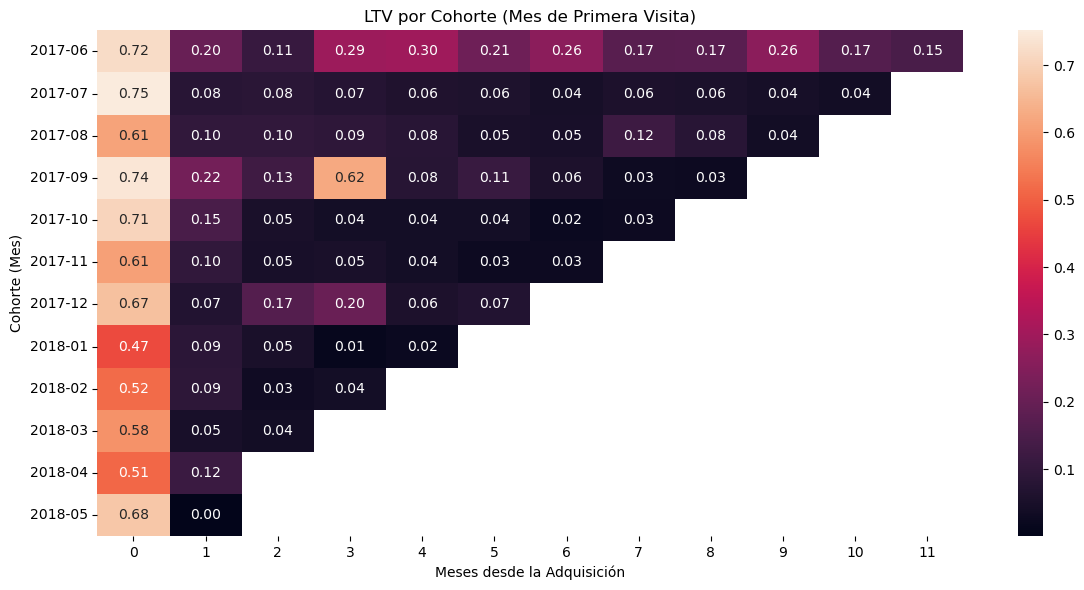

In [ ]:
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.heatmap(ltv, annot=True, fmt=".2f")
plt.title("LTV por Cohorte (Mes de Primera Visita)")
plt.xlabel("Meses desde la Adquisición")
plt.ylabel("Cohorte (Mes)")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('../reports/figures/LTV_por_cohorte.png', dpi=300, bbox_inches='tight')


Las cohortes más antiguas, especialmente las de junio, julio y septiembre de 2017, muestran un mayor LTV inicial (≥ 0.70) y un crecimiento más prolongado en los meses siguientes.

La cohorte de septiembre 2017 destaca por un pico de LTV en el tercer mes, lo que indica un comportamiento de compra significativo después del onboarding inicial.

A partir de enero de 2018, el LTV por cohorte es visiblemente menor y muestra una progresión más limitada, lo que sugiere una menor retención o menor frecuencia de compra en usuarios adquiridos en ese período.

Este patrón puede estar reflejando cambios en la calidad del tráfico, en la estrategia comercial, o en la experiencia de usuario para nuevos visitantes.



### C. Marketing
C.1) Gastos totales y por fuente a lo largo del tiempo.


,source_id,costs
0,1,20833.27
1,2,42806.04
2,3,141321.63
3,4,61073.60
4,5,51757.10
5,9,5517.49
6,10,5822.49


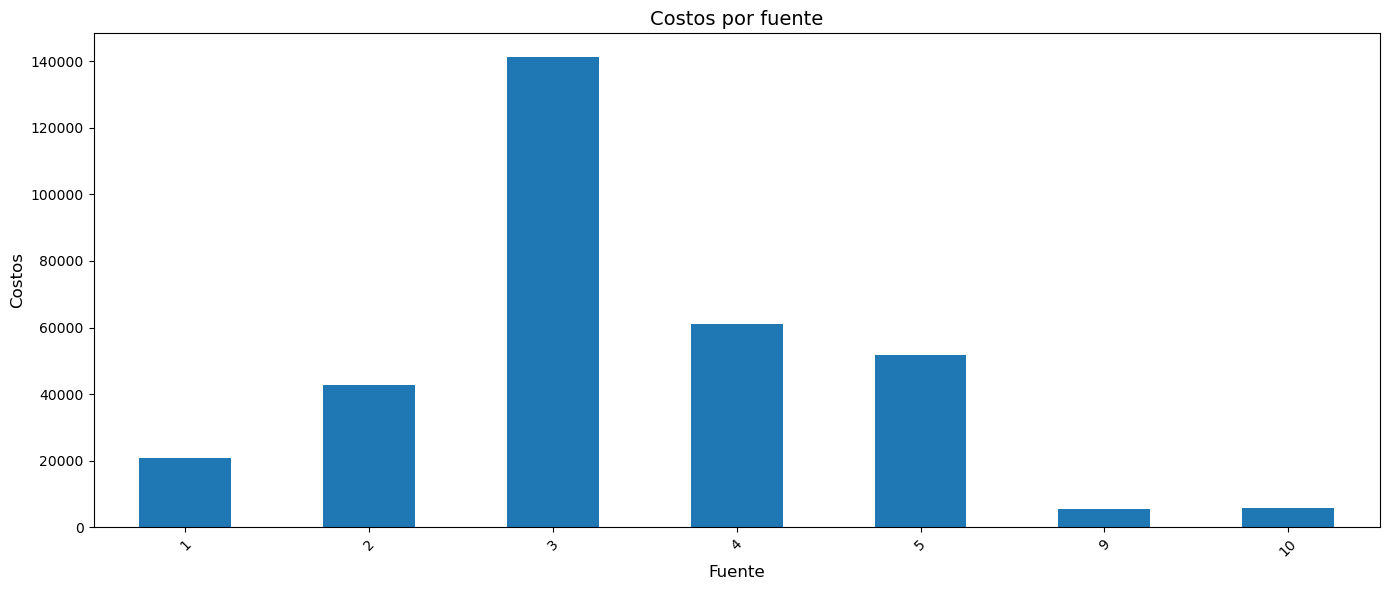

In [42]:
costos['dt'] = pd.to_datetime(costos['dt'])
costos_por_fuente = costos.groupby(['source_id'])['costs'].sum().reset_index()
fig, ax = plt.subplots(figsize=(14, 6))
ax.set_title('Costos por fuente', fontsize=14)
costos_por_fuente.plot(ax=ax, x='source_id', y='costs', kind='bar', legend=False)
plt.xlabel('Fuente', fontsize=12)
plt.ylabel('Costos', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/figures/costos_por_fuente.png', dpi=300, bbox_inches='tight')
costos_por_fuente


C.2) ¿Cuál fue el costo de adquisición de clientes de cada una de las fuentes? Customer Acqui-
sition Cost (CAC) por fuente.



C.3) ¿Cuán rentables eran las inversiones? Return on Marketing Investment (ROMI) temporal
y por fuente.

## Paso 3. Conclusiones y recomendaciones
Identifica las fuentes/ plataformas ganadoras: respáldalo con las métricas clave (LTV,
CAC, ROMI, retención).

Propón un presupuesto óptimo: monto y distribución de inversión.

Discute supuestos y limitaciones del análisis